EMAIL SPAM DETECTION

Dataset loaded successfully!
Dataset Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing Values:
label      0
message    0
dtype: int64

Duplicate Rows:
403

Duplicates removed: 403
New dataset shape: (5169, 2)

Class Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


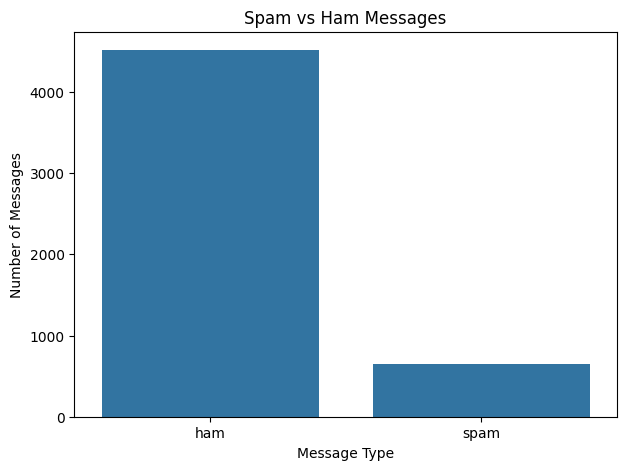


Text cleaning completed!


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...



Average message length:
label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64


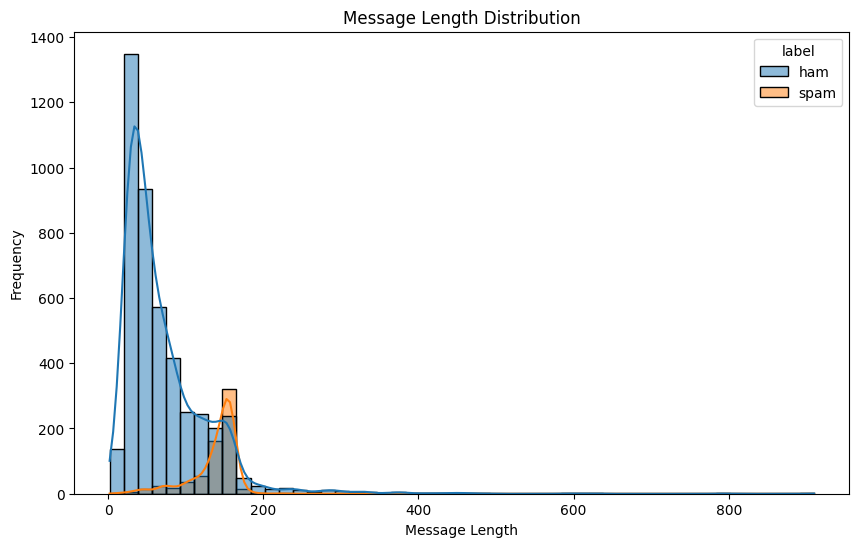


Training samples: 4135
Testing samples: 1034

TF-IDF completed!
Training matrix: (4135, 10000)
Testing matrix: (1034, 10000)

--------------------------------------------------
Multinomial Naive Bayes
--------------------------------------------------
Accuracy : 0.9623
Precision: 1.0
Recall   : 0.7023
F1 Score : 0.8251

Naive Bayes Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.70      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034


--------------------------------------------------
Logistic Regression
--------------------------------------------------
Accuracy : 0.9507
Precision: 0.9762
Recall   : 0.626
F1 Score : 0.7628

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         ham       0.9

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.962282,1.00000,0.702290,0.825112
1,Logistic Regression,0.950677,0.97619,0.625954,0.762791



Best Model: Multinomial Naive Bayes


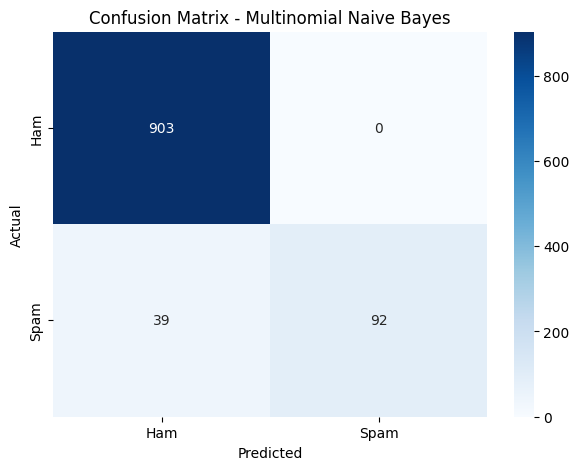

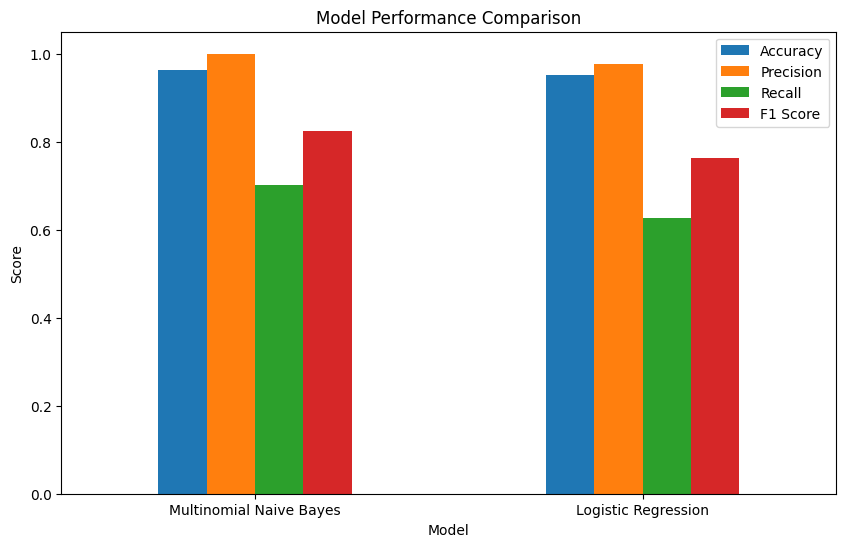


Message:
Congratulations! You have won a free prize. Click the link now to claim your reward!

Prediction:
SPAM

Message:
Hi, please send me the project report before tomorrow's meeting.

Prediction:
HAM / NOT SPAM

PROJECT COMPLETED SUCCESSFULLY!

Dataset: (5169, 4)

Models:
1. Multinomial Naive Bayes
2. Logistic Regression

Best Model:
Multinomial Naive Bayes

Techniques:
• Text Cleaning
• TF-IDF Vectorization
• Naive Bayes
• Logistic Regression
• Accuracy
• Precision
• Recall
• F1 Score
• Confusion Matrix


In [7]:

# ============================================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# TASK 4 - EMAIL SPAM DETECTION
# ============================================================

import zipfile
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATASET
# ============================================================

zip_path = "/content/sms+spam+collection.zip"

with zipfile.ZipFile(zip_path, "r") as z:

    df = pd.read_csv(
        z.open("SMSSpamCollection"),
        sep="\t",
        header=None,
        names=["label", "message"],
        encoding="utf-8"
    )

print("=" * 60)
print("EMAIL SPAM DETECTION")
print("=" * 60)

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())


# ============================================================
# 2. DATA INSPECTION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicates removed:", duplicates)
print("New dataset shape:", df.shape)


# ============================================================
# 4. CHECK CLASS DISTRIBUTION
# ============================================================

print("\nClass Distribution:")
print(df["label"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()


# ============================================================
# 5. TEXT CLEANING
# ============================================================

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Remove special characters
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_message"] = df["message"].apply(clean_text)

print("\nText cleaning completed!")

display(
    df[["label", "message", "clean_message"]].head()
)


# ============================================================
# 6. MESSAGE LENGTH FEATURE
# ============================================================

df["message_length"] = df["message"].str.len()

print("\nAverage message length:")
print(
    df.groupby("label")["message_length"].mean()
)


plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()


# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 8. TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF completed!")

print(
    "Training matrix:",
    X_train_tfidf.shape
)

print(
    "Testing matrix:",
    X_test_tfidf.shape
)


# ============================================================
# 9. MODEL 1 - NAIVE BAYES
# ============================================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)


# ============================================================
# 10. MODEL 2 - LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(
    X_test_tfidf
)


# ============================================================
# 11. EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, actual, predicted):

    accuracy = accuracy_score(
        actual,
        predicted
    )

    precision = precision_score(
        actual,
        predicted,
        pos_label="spam"
    )

    recall = recall_score(
        actual,
        predicted,
        pos_label="spam"
    )

    f1 = f1_score(
        actual,
        predicted,
        pos_label="spam"
    )

    print("\n" + "-" * 50)
    print(name)
    print("-" * 50)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    return accuracy, precision, recall, f1


# ============================================================
# 12. NAIVE BAYES RESULTS
# ============================================================

nb_accuracy, nb_precision, nb_recall, nb_f1 = evaluate_model(
    "Multinomial Naive Bayes",
    y_test,
    nb_predictions
)

print("\nNaive Bayes Classification Report:")

print(
    classification_report(
        y_test,
        nb_predictions
    )
)


# ============================================================
# 13. LOGISTIC REGRESSION RESULTS
# ============================================================

lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions
)

print("\nLogistic Regression Classification Report:")

print(
    classification_report(
        y_test,
        lr_predictions
    )
)


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],

    "Precision": [
        nb_precision,
        lr_precision
    ],

    "Recall": [
        nb_recall,
        lr_recall
    ],

    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(comparison)


# ============================================================
# 15. SELECT BEST MODEL
# ============================================================

if lr_f1 > nb_f1:

    best_model = lr_model
    best_predictions = lr_predictions
    best_model_name = "Logistic Regression"

else:

    best_model = nb_model
    best_predictions = nb_predictions
    best_model_name = "Multinomial Naive Bayes"


print("\nBest Model:", best_model_name)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=["ham", "spam"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title(
    "Confusion Matrix - " + best_model_name
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================================
# 17. PERFORMANCE COMPARISON GRAPH
# ============================================================

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()


# ============================================================
# 18. CUSTOM MESSAGE PREDICTION
# ============================================================

def predict_message(message):

    cleaned = clean_text(message)

    vector = tfidf.transform([cleaned])

    prediction = best_model.predict(vector)[0]

    if prediction == "spam":

        result = "SPAM"

    else:

        result = "HAM / NOT SPAM"

    print("\nMessage:")
    print(message)

    print("\nPrediction:")
    print(result)

    return result


# ============================================================
# 19. TEST EXAMPLES
# ============================================================

predict_message(
    "Congratulations! You have won a free prize. "
    "Click the link now to claim your reward!"
)

predict_message(
    "Hi, please send me the project report before "
    "tomorrow's meeting."
)


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("\nDataset:", df.shape)

print("\nModels:")
print("1. Multinomial Naive Bayes")
print("2. Logistic Regression")

print("\nBest Model:")
print(best_model_name)

print("\nTechniques:")
print("• Text Cleaning")
print("• TF-IDF Vectorization")
print("• Naive Bayes")
print("• Logistic Regression")
print("• Accuracy")
print("• Precision")
print("• Recall")
print("• F1 Score")
print("• Confusion Matrix")
